# Day 2-1: Seq2Seq 기초 — 데이터 탐색 & BLEU Score

**강의 시간**: 1.5시간  
**학습 목표**:
- 병렬 코퍼스(Parallel Corpus)의 구조와 특성 이해
- 토큰화(Tokenization)와 Vocabulary 구축 원리 습득
- 번역 평가 지표 BLEU Score 직접 계산하며 직관 쌓기
- Seq2Seq 입력 형식으로 데이터 전처리 (패딩 / SOS / EOS 토큰)
- MLflow로 데이터 탐색 실험 기록

**사전 요구사항**: Day 1-3 완료, Dagshub 계정 및 MLflow 연동 경험  
**사용 데이터**: [Tatoeba Translation Dataset](https://tatoeba.org/en/downloads) (CC BY 2.0, 상업적 사용 가능)


## 🔧 0. 환경 설정

새 노트북을 시작하므로 필요한 라이브러리를 설치하고 기본 설정을 로드합니다.

In [ ]:
# 라이브러리 설치 (약 30~60초 소요)
%pip install -q sacrebleu 'mlflow>=2,<3' dagshub

# NLTK punkt tokenizer 다운로드
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 146.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.2/263.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# 라이브러리 임포트
import os
import re
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
import torch.nn as nn
from nltk.tokenize import word_tokenize
import sacrebleu
import mlflow
import dagshub
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ CUDA available  : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device    : {device}")

In [ ]:
# Dagshub & MLflow 연동
# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(
    repo_owner=repo_owner,
    repo_name=repo_name,
    mlflow=True
)

mlflow.set_experiment('day2-translation-seq2seq')

print("✅ Dagshub 연동 완료!")
print(f"   Tracking URI: {mlflow.get_tracking_uri()}")

## 📂 1. 데이터 로드

### 1.1 Tatoeba 데이터셋 소개

[Tatoeba](https://tatoeba.org)는 자원봉사자들이 구축한 다국어 문장 데이터베이스로,  
CC BY 2.0 라이선스로 제공되어 교육 및 상업적 활용이 모두 가능합니다.

우리는 **영어(EN) → 독일어(DE)** 번역 쌍을 사용합니다:
- 단어 어순이 달라 Seq2Seq 모델의 필요성을 체감하기 쉬움
- 어휘 크기가 적당해 교육용으로 최적
- 학습 이후 Day 2-2에서 바로 모델 학습에 활용

In [5]:
import os
import urllib.request

DATA_URL  = 'https://www.manythings.org/anki/deu-eng.zip'
ZIP_PATH  = 'deu-eng.zip'
DATA_PATH = 'deu.txt'

if not os.path.exists(DATA_PATH):
    print("📥 데이터 다운로드 중... (약 5-10초)")

    # 헤더 설정 (브라우저인 것처럼 위장)
    opener = urllib.request.build_opener()
    opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')]
    urllib.request.install_opener(opener)

    try:
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

        import zipfile
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall('.')
        print("✅ 다운로드 & 압축 해제 완료!")
    except Exception as e:
        print(f"❌ 에러 발생: {e}")
else:
    print("✅ 이미 다운로드된 파일 사용!")

📥 데이터 다운로드 중... (약 5-10초)
✅ 다운로드 & 압축 해제 완료!


In [6]:
# 파일 파싱 — 탭으로 분리된 EN \t DE 형식
pairs = []
with open(DATA_PATH, encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            en, de = parts[0], parts[1]
            pairs.append({'english': en, 'german': de})

all_df = pd.DataFrame(pairs)
print(f"✅ 전체 문장 쌍: {len(all_df):,}개")
all_df.head()

✅ 전체 문장 쌍: 331,266개


,english,german
0,Go.,Geh.
1,Hi.,Hallo!
2,Hi.,Grüß Gott!
3,Run!,Lauf!
4,Run.,Lauf!


In [7]:
# ---------------------------------------------------------------
# 교육용 서브셋: 짧은 문장(단어 3~12개) 위주로 5,000개 샘플링
# → 학습 속도 확보 + 단순한 패턴으로 원리 파악에 집중
# ---------------------------------------------------------------
NUM_SAMPLES = 5000
MAX_WORDS   = 12
MIN_WORDS   = 3

all_df['en_wc'] = all_df['english'].apply(lambda x: len(x.split()))
filtered = all_df[
    (all_df['en_wc'] >= MIN_WORDS) &
    (all_df['en_wc'] <= MAX_WORDS)
].copy()

df = filtered.sample(n=NUM_SAMPLES, random_state=42).reset_index(drop=True)

print(f"✅ 샘플링 완료: {len(df):,}개 (필터 후 전체 {len(filtered):,}개 중)")
print(f"   단어 수 기준: {MIN_WORDS}~{MAX_WORDS}개")
print()
print("샘플 확인:")
for i in range(5):
    print(f"  EN: {df.iloc[i]['english']}")
    print(f"  DE: {df.iloc[i]['german']}")
    print()

✅ 샘플링 완료: 5,000개 (필터 후 전체 318,572개 중)
   단어 수 기준: 3~12개

샘플 확인:
  EN: A little more effort, and you will succeed.
  DE: Ein bisschen mehr Anstrengung, und du schaffst es.

  EN: Shall I sing you something?
  DE: Soll ich dir etwas vorsingen?

  EN: Tom showed reckless disregard for Mary's feelings.
  DE: Tom legte eine rücksichtslose Missachtung der Gefühle Marias an den Tag.

  EN: He asked if I like Chinese food.
  DE: Er fragte, ob ich gern chinesisch äße.

  EN: You look like you're about to throw up.
  DE: Du siehst aus, als müsstest du dich gleich übergeben!



## 📊 2. 탐색적 데이터 분석 (EDA)

### 2.1 문장 길이 분포

In [8]:
# 단어 수 / 글자 수 계산
df['en_word_count'] = df['english'].apply(lambda x: len(x.split()))
df['de_word_count'] = df['german'].apply(lambda x: len(x.split()))
df['en_char_count'] = df['english'].apply(len)
df['de_char_count'] = df['german'].apply(len)

# 길이 비율 (독일어/영어): 독일어는 복합어가 많아 단어 수는 줄고 글자 수는 늘어남
df['word_ratio'] = df['de_word_count'] / df['en_word_count']

print("=" * 55)
print(f"{'항목':<20} {'영어':>10} {'독일어':>10}")
print("=" * 55)
for (en_col, de_col), label in [(('en_word_count', 'de_word_count'), '단어 수'),
                                 (('en_char_count', 'de_char_count'), '글자 수')]:
    pass  # 아래에서 직접 출력

print(f"{'평균 단어 수':<20} {df['en_word_count'].mean():>10.2f} {df['de_word_count'].mean():>10.2f}")
print(f"{'최대 단어 수':<20} {df['en_word_count'].max():>10} {df['de_word_count'].max():>10}")
print(f"{'평균 글자 수':<20} {df['en_char_count'].mean():>10.2f} {df['de_char_count'].mean():>10.2f}")
print(f"{'최대 글자 수':<20} {df['en_char_count'].max():>10} {df['de_char_count'].max():>10}")
print("=" * 55)
print(f"\n📌 단어 수 비율 (DE/EN) 평균: {df['word_ratio'].mean():.3f}")
print("   → 독일어가 영어보다 단어 수가 평균 {:.0f}% 수준 (복합어 영향)".format(
      df['word_ratio'].mean() * 100))

항목                           영어        독일어
평균 단어 수                    6.30       6.32
최대 단어 수                      12         16
평균 글자 수                   31.39      36.48
최대 글자 수                      76         92

📌 단어 수 비율 (DE/EN) 평균: 1.025
   → 독일어가 영어보다 단어 수가 평균 103% 수준 (복합어 영향)


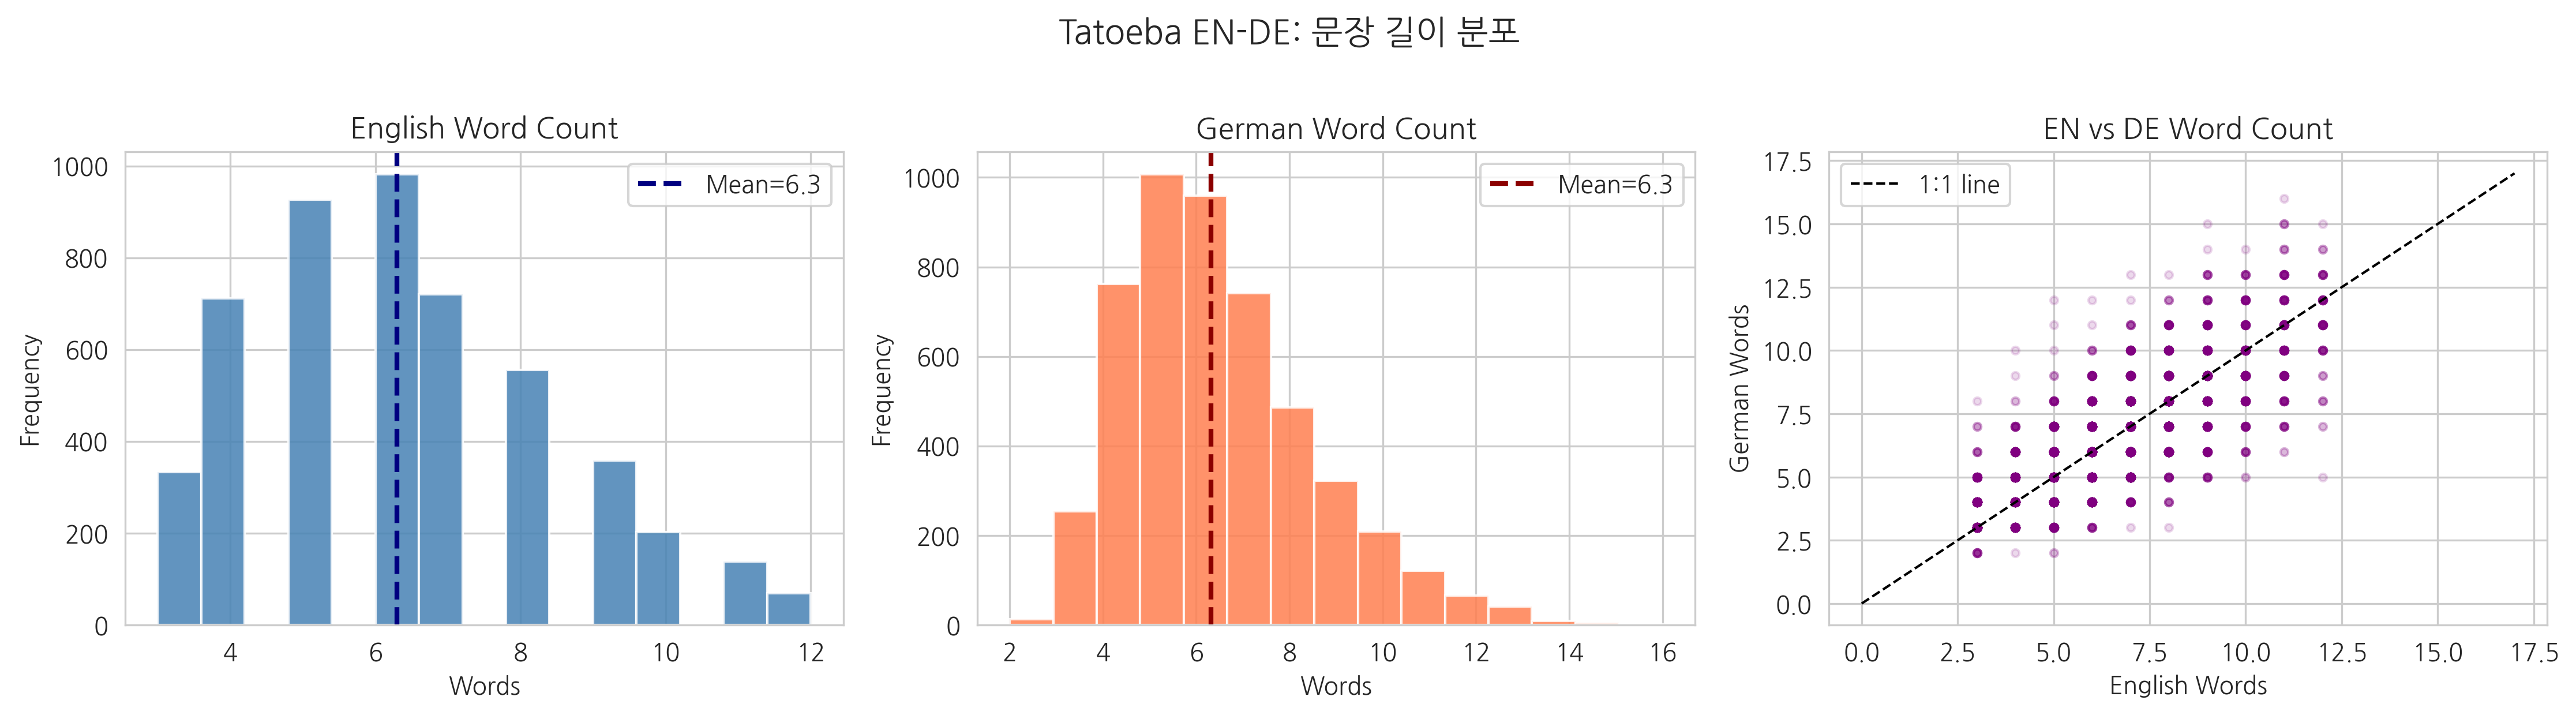

💡 Insight: 독일어는 복합어(Komposita) 특성으로 단어 수가 영어보다 적을 수 있지만,
   글자 수는 오히려 더 긴 경향이 있습니다. → 패딩 전략에 영향을 줍니다!


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) 영어 단어 수 분포
axes[0].hist(df['en_word_count'], bins=15, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(df['en_word_count'].mean(), color='navy', linestyle='--',
                linewidth=2, label=f"Mean={df['en_word_count'].mean():.1f}")
axes[0].set_title('English Word Count', fontweight='bold')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2) 독일어 단어 수 분포
axes[1].hist(df['de_word_count'], bins=15, color='coral',
             edgecolor='white', alpha=0.85)
axes[1].axvline(df['de_word_count'].mean(), color='darkred', linestyle='--',
                linewidth=2, label=f"Mean={df['de_word_count'].mean():.1f}")
axes[1].set_title('German Word Count', fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# 3) EN vs DE 단어 수 산점도
axes[2].scatter(df['en_word_count'], df['de_word_count'],
                alpha=0.15, color='purple', s=10)
# 1:1 기준선
lim = max(df['en_word_count'].max(), df['de_word_count'].max()) + 1
axes[2].plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
axes[2].set_title('EN vs DE Word Count', fontweight='bold')
axes[2].set_xlabel('English Words')
axes[2].set_ylabel('German Words')
axes[2].legend()

plt.suptitle('Tatoeba EN-DE: 문장 길이 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("💡 Insight: 독일어는 복합어(Komposita) 특성으로 단어 수가 영어보다 적을 수 있지만,")
print("   글자 수는 오히려 더 긴 경향이 있습니다. → 패딩 전략에 영향을 줍니다!")

### 2.2 어휘 분포 (Zipf's Law)

In [12]:
# 전체 단어 빈도 계산
en_all_words = [w.lower() for sent in df['english'] for w in sent.split()]
de_all_words = [w.lower() for sent in df['german']  for w in sent.split()]

en_freq = Counter(en_all_words)
de_freq = Counter(de_all_words)

print(f"📊 영어 고유 단어 수  : {len(en_freq):,}")
print(f"📊 독일어 고유 단어 수: {len(de_freq):,}")
print()
print("[영어 Top-20]")
for w, c in en_freq.most_common(20):
    bar = '█' * min(c // 20, 30)
    print(f"  {w:<15} {c:>5}  {bar}")
print()
print("[독일어 Top-20]")
for w, c in de_freq.most_common(20):
    bar = '█' * min(c // 20, 30)
    print(f"  {w:<20} {c:>5}  {bar}")

📊 영어 고유 단어 수  : 4,754
📊 독일어 고유 단어 수: 6,503

[영어 Top-20]
  you              1199  ██████████████████████████████
  tom              1108  ██████████████████████████████
  i                1092  ██████████████████████████████
  to               1088  ██████████████████████████████
  the              1063  ██████████████████████████████
  a                 650  ██████████████████████████████
  is                507  █████████████████████████
  do                374  ██████████████████
  that              327  ████████████████
  in                311  ███████████████
  have              294  ██████████████
  of                291  ██████████████
  don't             289  ██████████████
  was               275  █████████████
  he                252  ████████████
  what              230  ███████████
  it                219  ██████████
  for               218  ██████████
  this              217  ██████████
  are               212  ██████████

[독일어 Top-20]
  ich                   1372  ████████

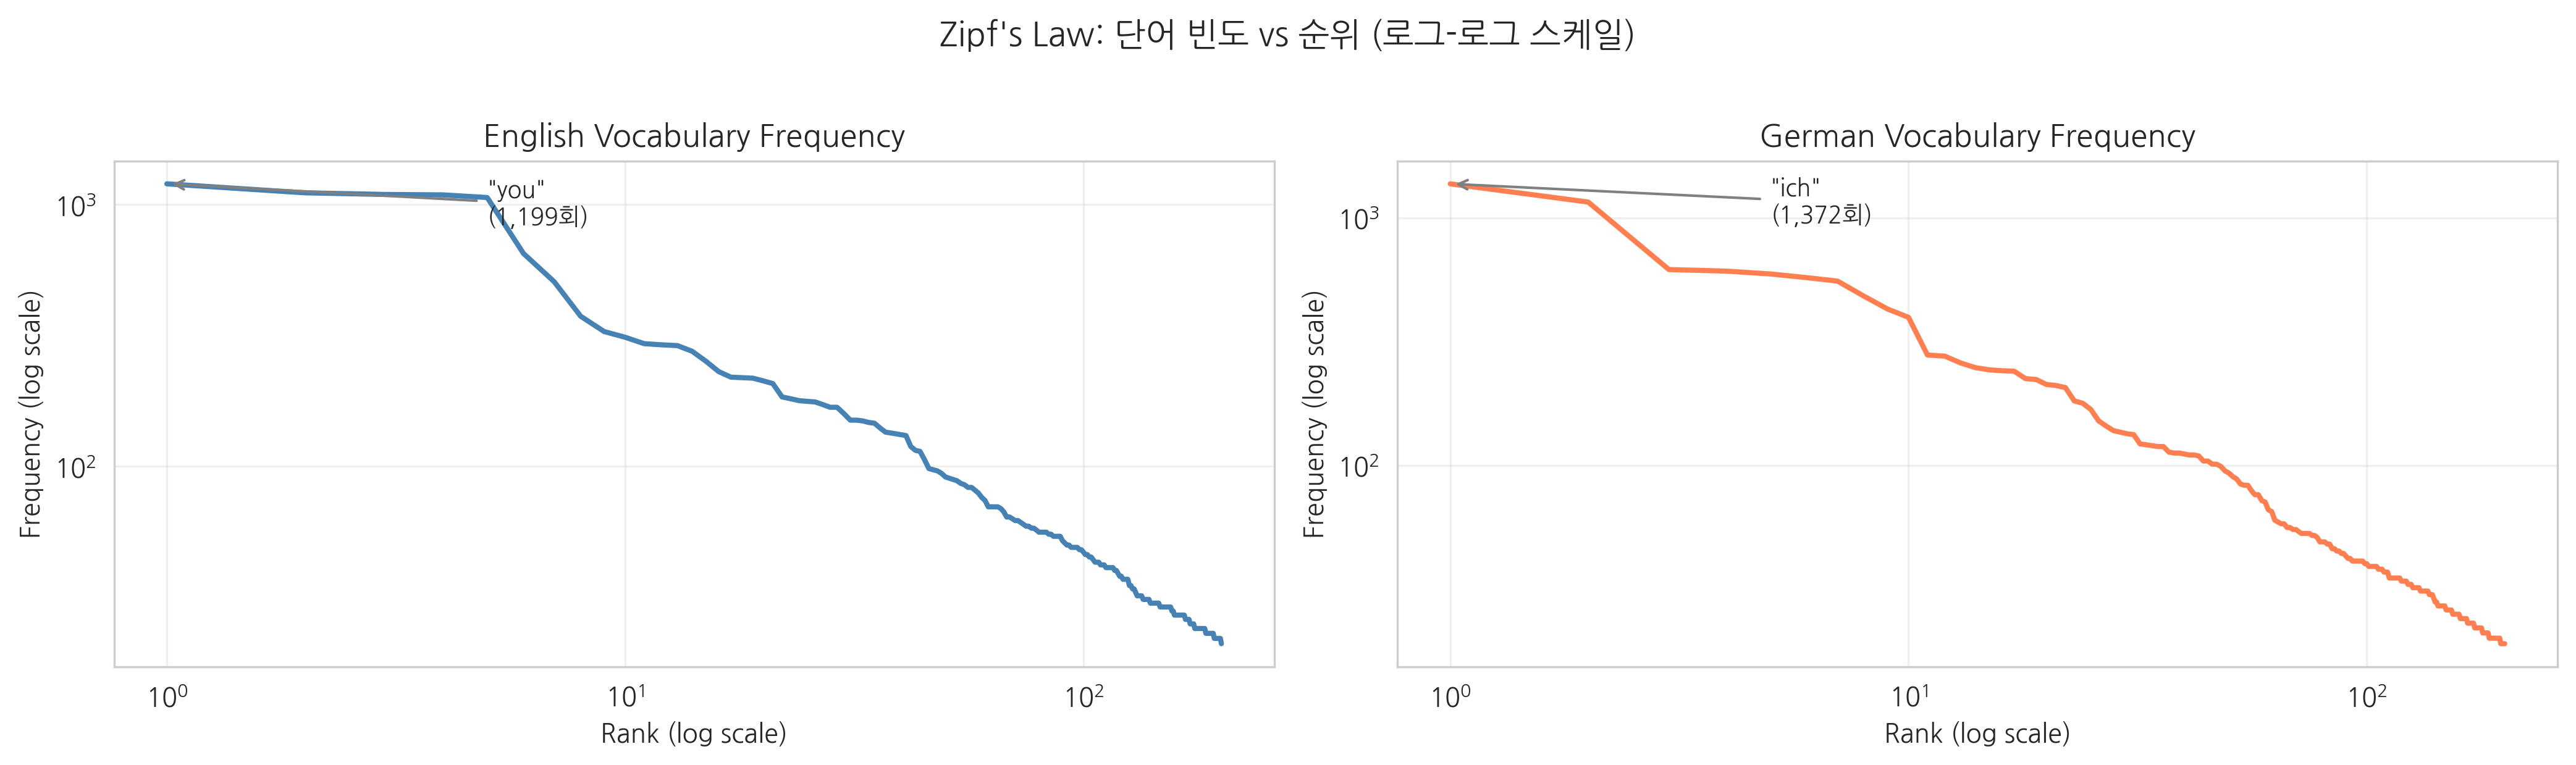

💡 Zipf's Law: 로그-로그 그래프에서 직선 → 소수의 단어가 텍스트의 대부분을 차지
   이것이 바로 <UNK> 토큰이 필요한 이유입니다!


In [16]:
# Zipf's Law 시각화 — 상위 500개 단어 빈도
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, freq, title, color in [
    (axes[0], en_freq, 'English Vocabulary Frequency', 'steelblue'),
    (axes[1], de_freq, 'German Vocabulary Frequency',  'coral'),
]:
    top_n = 200
    words, counts = zip(*freq.most_common(top_n))
    ranks = np.arange(1, top_n + 1)

    ax.loglog(ranks, counts, color=color, linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Rank (log scale)')
    ax.set_ylabel('Frequency (log scale)')
    ax.grid(True, alpha=0.3)

    # 1등 단어 표시
    ax.annotate(f'"{words[0]}"\n({counts[0]:,}회)',
                xy=(1, counts[0]), xytext=(5, counts[0] * 0.7),
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=9)

plt.suptitle("Zipf's Law: 단어 빈도 vs 순위 (로그-로그 스케일)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('zipf_law.png', dpi=100, bbox_inches='tight')
plt.show()

print("💡 Zipf's Law: 로그-로그 그래프에서 직선 → 소수의 단어가 텍스트의 대부분을 차지")
print("   이것이 바로 <UNK> 토큰이 필요한 이유입니다!")

## 🔤 3. 토큰화 (Tokenization)

### 3.1 왜 토큰화가 중요한가?

신경망은 **숫자** 만 처리할 수 있습니다. 문자 → 숫자로 변환하는 과정이 토큰화입니다.

```
"I love you"  →  [1(SOS), 5(i), 23(love), 42(you), 2(EOS), 0(PAD), 0(PAD)]
"Ich liebe dich"  →  [1(SOS), 7(ich), 31(liebe), 15(dich), 2(EOS), 0(PAD), 0(PAD)]
```

특수 토큰의 역할:
- **`<PAD>`** (idx=0): 짧은 문장을 동일한 길이로 맞추기 위한 패딩
- **`<SOS>`** (idx=1): Start Of Sequence — 디코더가 생성을 시작하는 신호
- **`<EOS>`** (idx=2): End Of Sequence — 생성이 끝났음을 알리는 신호  
- **`<UNK>`** (idx=3): Unknown — 사전에 없는 단어 처리

In [17]:
def tokenize(text: str) -> list:
    """
    텍스트를 단어 토큰 리스트로 변환
    - 소문자 변환
    - NLTK word_tokenize 사용 (구두점 분리 포함)
    """
    return word_tokenize(text.lower())


# --- 실습: 토큰화 비교 ---
examples = [
    ("I love you!", "영어 (단순)"),
    ("It's a beautiful day, isn't it?", "영어 (축약어/구두점)"),
    ("Ich liebe dich sehr.", "독일어"),
    ("Das Fußballspiel war spannend!", "독일어 (복합어)"),
]

print("=" * 65)
print(f"{'원문':<40} {'토큰':<25}")
print("=" * 65)
for text, label in examples:
    tokens = tokenize(text)
    print(f"[{label}]")
    print(f"  원문  : {text}")
    print(f"  토큰  : {tokens}")
    print(f"  길이  : {len(tokens)}")
    print()

print("💡 독일어 'Fußball'(축구)처럼 복합어가 한 토큰으로 처리됩니다.")
print("   더 정교한 처리를 원하면 spaCy나 SentencePiece를 사용합니다.")

원문                                       토큰                       
[영어 (단순)]
  원문  : I love you!
  토큰  : ['i', 'love', 'you', '!']
  길이  : 4

[영어 (축약어/구두점)]
  원문  : It's a beautiful day, isn't it?
  토큰  : ['it', "'s", 'a', 'beautiful', 'day', ',', 'is', "n't", 'it', '?']
  길이  : 10

[독일어]
  원문  : Ich liebe dich sehr.
  토큰  : ['ich', 'liebe', 'dich', 'sehr', '.']
  길이  : 5

[독일어 (복합어)]
  원문  : Das Fußballspiel war spannend!
  토큰  : ['das', 'fußballspiel', 'war', 'spannend', '!']
  길이  : 5

💡 독일어 'Fußball'(축구)처럼 복합어가 한 토큰으로 처리됩니다.
   더 정교한 처리를 원하면 spaCy나 SentencePiece를 사용합니다.


In [18]:
# 전체 데이터 토큰화
df['en_tokens'] = df['english'].apply(tokenize)
df['de_tokens'] = df['german'].apply(tokenize)

print("✅ 토큰화 완료!")
print()
df[['english', 'en_tokens', 'german', 'de_tokens']].head()

✅ 토큰화 완료!



,english,en_tokens,german,de_tokens
0,"A little more effort, and you will succeed.","[a, little, more, effort, ,, and, you, will, s...","Ein bisschen mehr Anstrengung, und du schaffst...","[ein, bisschen, mehr, anstrengung, ,, und, du,..."
1,Shall I sing you something?,"[shall, i, sing, you, something, ?]",Soll ich dir etwas vorsingen?,"[soll, ich, dir, etwas, vorsingen, ?]"
2,Tom showed reckless disregard for Mary's feeli...,"[tom, showed, reckless, disregard, for, mary, ...",Tom legte eine rücksichtslose Missachtung der ...,"[tom, legte, eine, rücksichtslose, missachtung..."
3,He asked if I like Chinese food.,"[he, asked, if, i, like, chinese, food, .]","Er fragte, ob ich gern chinesisch äße.","[er, fragte, ,, ob, ich, gern, chinesisch, äße..."
4,You look like you're about to throw up.,"[you, look, like, you, 're, about, to, throw, ...","Du siehst aus, als müsstest du dich gleich übe...","[du, siehst, aus, ,, als, müsstest, du, dich, ..."


## 📚 4. Vocabulary 구축

### 4.1 Vocabulary 클래스

Vocabulary는 **단어(string) ↔ 인덱스(int)** 간의 양방향 매핑을 관리합니다.

```
stoi (str→int):  {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3, "i": 4, ...}
itos (int→str):  {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>", 4: "i", ...}
```

`freq_threshold` 파라미터로 희귀 단어를 `<UNK>`로 처리합니다 (보통 1~2회 이하).  
이를 통해 **어휘 크기를 줄이고 일반화 성능을 높입니다.**

In [19]:
class Vocabulary:
    """단어-인덱스 양방향 매핑 관리 클래스"""

    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, freq_threshold: int = 1):
        self.freq_threshold = freq_threshold
        # 특수 토큰으로 초기화
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    def __repr__(self):
        return f"Vocabulary(size={len(self)}, freq_threshold={self.freq_threshold})"

    def build(self, token_lists: list):
        """
        토큰 리스트 목록에서 어휘 사전 구축
        token_lists: [[token, ...], [token, ...], ...]
        """
        freq = Counter(tok for tokens in token_lists for tok in tokens)

        idx = 4  # 특수 토큰 이후부터 시작
        for word, count in sorted(freq.items()):  # 정렬로 재현성 확보
            if count >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx]  = word
                idx += 1

    def encode(self, tokens: list) -> list:
        """토큰 리스트 → 인덱스 리스트 (UNK 처리 포함)"""
        return [self.stoi.get(t, self.UNK) for t in tokens]

    def decode(self, indices: list, skip_special: bool = True) -> str:
        """인덱스 리스트 → 원문 복원"""
        special = {self.PAD, self.SOS, self.EOS} if skip_special else set()
        return ' '.join(self.itos.get(i, '<UNK>') for i in indices
                        if i not in special)

    def unk_rate(self, token_lists: list) -> float:
        """전체 토큰 중 <UNK>로 처리되는 비율"""
        total, unk = 0, 0
        for tokens in token_lists:
            for t in tokens:
                total += 1
                if t not in self.stoi:
                    unk += 1
        return unk / total if total > 0 else 0.0

print("✅ Vocabulary 클래스 정의 완료!")

✅ Vocabulary 클래스 정의 완료!


In [20]:
# Train/Validation 분리 (80/20)
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"✅ 데이터 분리: train={len(train_df):,}개 / val={len(val_df):,}개")

# 어휘 사전 구축 (train만 사용 — 데이터 누수 방지)
en_vocab = Vocabulary(freq_threshold=2)
de_vocab = Vocabulary(freq_threshold=2)

en_vocab.build(train_df['en_tokens'].tolist())
de_vocab.build(train_df['de_tokens'].tolist())

print()
print(f"📖 {en_vocab}")
print(f"📖 {de_vocab}")
print()

# UNK 비율 확인 (낮을수록 좋음)
en_unk = en_vocab.unk_rate(val_df['en_tokens'].tolist())
de_unk = de_vocab.unk_rate(val_df['de_tokens'].tolist())
print(f"❓ Validation UNK 비율 — 영어: {en_unk:.2%}  |  독일어: {de_unk:.2%}")
print("   (5% 미만이면 어휘 사전이 충분히 커버하고 있음)")

✅ 데이터 분리: train=4,000개 / val=1,000개

📖 Vocabulary(size=1380, freq_threshold=2)
📖 Vocabulary(size=1647, freq_threshold=2)

❓ Validation UNK 비율 — 영어: 7.29%  |  독일어: 11.61%
   (5% 미만이면 어휘 사전이 충분히 커버하고 있음)


In [21]:
# 인코딩/디코딩 왕복 테스트
test_cases = [
    ("I love you", 'en'),
    ("Ich liebe dich", 'de'),
    ("The weather is nice today", 'en'),
]

print("=" * 65)
print("인코딩 → 디코딩 왕복 테스트")
print("=" * 65)
for text, lang in test_cases:
    vocab  = en_vocab if lang == 'en' else de_vocab
    tokens = tokenize(text)
    ids    = vocab.encode(tokens)
    # SOS / EOS 추가
    full_ids = [vocab.SOS] + ids + [vocab.EOS]
    decoded  = vocab.decode(full_ids)

    print(f"원문   : {text}")
    print(f"토큰   : {tokens}")
    print(f"ID     : {full_ids}")
    print(f"복원   : {decoded}")
    print()

인코딩 → 디코딩 왕복 테스트
원문   : I love you
토큰   : ['i', 'love', 'you']
ID     : [1, 584, 706, 1374, 2]
복원   : i love you

원문   : Ich liebe dich
토큰   : ['ich', 'liebe', 'dich']
ID     : [1, 715, 907, 279, 2]
복원   : ich liebe dich

원문   : The weather is nice today
토큰   : ['the', 'weather', 'is', 'nice', 'today']
ID     : [1, 1198, 1315, 605, 795, 1230, 2]
복원   : the weather is nice today



## 🎯 5. BLEU Score — 번역 품질 평가 지표

### 5.1 BLEU Score란?

**BLEU** (Bilingual Evaluation Understudy)는 기계 번역 품질을 자동으로 평가하는 지표입니다 (Papineni et al., 2002).

핵심 아이디어: **번역 결과에서 n-gram이 참조 번역과 얼마나 겹치는가?**

$$\text{BLEU} = BP \times \exp\left( \sum_{n=1}^{N} w_n \log p_n \right)$$

- $p_n$: n-gram precision (1-gram, 2-gram, 3-gram, 4-gram)
- $BP$: Brevity Penalty (너무 짧은 번역에 패널티)
- 범위: **0 ~ 100** (100이 완벽한 번역)

실무 기준:
| BLEU | 품질 수준 |
|------|----------|
| < 10 | 거의 쓸 수 없는 번역 |
| 10–19 | 어느 정도 이해 가능 |
| 20–29 | 이해 가능, 오류 많음 |
| 30–49 | 충분히 이해 가능 |
| 50+ | 전문가 수준 번역 |

> 💡 **주의**: BLEU는 단어 순서만 부분적으로 반영하고, 의미적 유사성은 측정하지 못합니다.  
> 최근에는 BERTScore 등 임베딩 기반 지표가 함께 사용됩니다.

In [22]:
# sacrebleu를 사용한 BLEU 계산
def sentence_bleu(hypothesis: str, reference: str) -> float:
    """단일 문장 BLEU 계산 (sacrebleu)"""
    result = sacrebleu.sentence_bleu(hypothesis, [reference])
    return result.score

def corpus_bleu(hypotheses: list, references: list) -> float:
    """코퍼스 전체 BLEU 계산"""
    result = sacrebleu.corpus_bleu(hypotheses, [references])
    return result.score

# 직관을 키우기 위한 예시
reference = "The cat is sitting on the mat"
hypotheses = [
    ("The cat is sitting on the mat",  "완벽한 번역"),
    ("The cat is on the mat",           "단어 1개 삭제"),
    ("A cat is sitting on a mat",       "관사 변경"),
    ("The dog is sitting on the mat",   "핵심 단어 오류"),
    ("Cat mat sitting the on is",       "순서 뒤섞임"),
    ("The cat",                          "매우 짧은 번역"),
]

print(f"Reference: \"{reference}\"")
print()
print(f"{'번역 유형':<20} {'번역문':<45} {'BLEU':>6}")
print("-" * 75)
for hyp, label in hypotheses:
    score = sentence_bleu(hyp, reference)
    bar   = '▓' * int(score / 3)
    print(f"{label:<20} {hyp:<45} {score:>5.1f}  {bar}")

Reference: "The cat is sitting on the mat"

번역 유형                번역문                                             BLEU
---------------------------------------------------------------------------
완벽한 번역               The cat is sitting on the mat                 100.0  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
단어 1개 삭제             The cat is on the mat                          43.0  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
관사 변경                A cat is sitting on a mat                      43.5  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
핵심 단어 오류             The dog is sitting on the mat                  64.3  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
순서 뒤섞임               Cat mat sitting the on is                      10.3  ▓▓▓
매우 짧은 번역             The cat                                         8.2  ▓▓


In [23]:
# n-gram 직접 계산으로 BLEU 직관 쌓기
def get_ngrams(tokens: list, n: int) -> Counter:
    """n-gram Counter 반환"""
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

def ngram_precision(hyp_tokens: list, ref_tokens: list, n: int) -> tuple:
    """n-gram precision 계산 (분자, 분모, 비율)"""
    hyp_ngrams = get_ngrams(hyp_tokens, n)
    ref_ngrams = get_ngrams(ref_tokens, n)

    # 클리핑: 최대 ref에서 나온 횟수까지만 인정
    clipped = sum(min(count, ref_ngrams[gram]) for gram, count in hyp_ngrams.items())
    total   = sum(hyp_ngrams.values())
    return clipped, total, clipped / total if total > 0 else 0.0

ref_tokens = reference.lower().split()
hyp_tokens = "The cat is sitting on a mat".lower().split()

print(f"Reference : {' '.join(ref_tokens)}")
print(f"Hypothesis: {' '.join(hyp_tokens)}")
print()
print(f"{'n-gram':<10} {'맞음/전체':>12} {'Precision':>10}")
print("-" * 35)
for n in [1, 2, 3, 4]:
    clipped, total, prec = ngram_precision(hyp_tokens, ref_tokens, n)
    print(f"{n}-gram     {clipped:>5}/{total:<5}       {prec:.3f}")
print()
print(f"sacrebleu BLEU: {sentence_bleu(' '.join(hyp_tokens), reference):.2f}")

Reference : the cat is sitting on the mat
Hypothesis: the cat is sitting on a mat

n-gram            맞음/전체  Precision
-----------------------------------
1-gram         6/7           0.857
2-gram         4/6           0.667
3-gram         3/5           0.600
4-gram         2/4           0.500

sacrebleu BLEU: 45.50


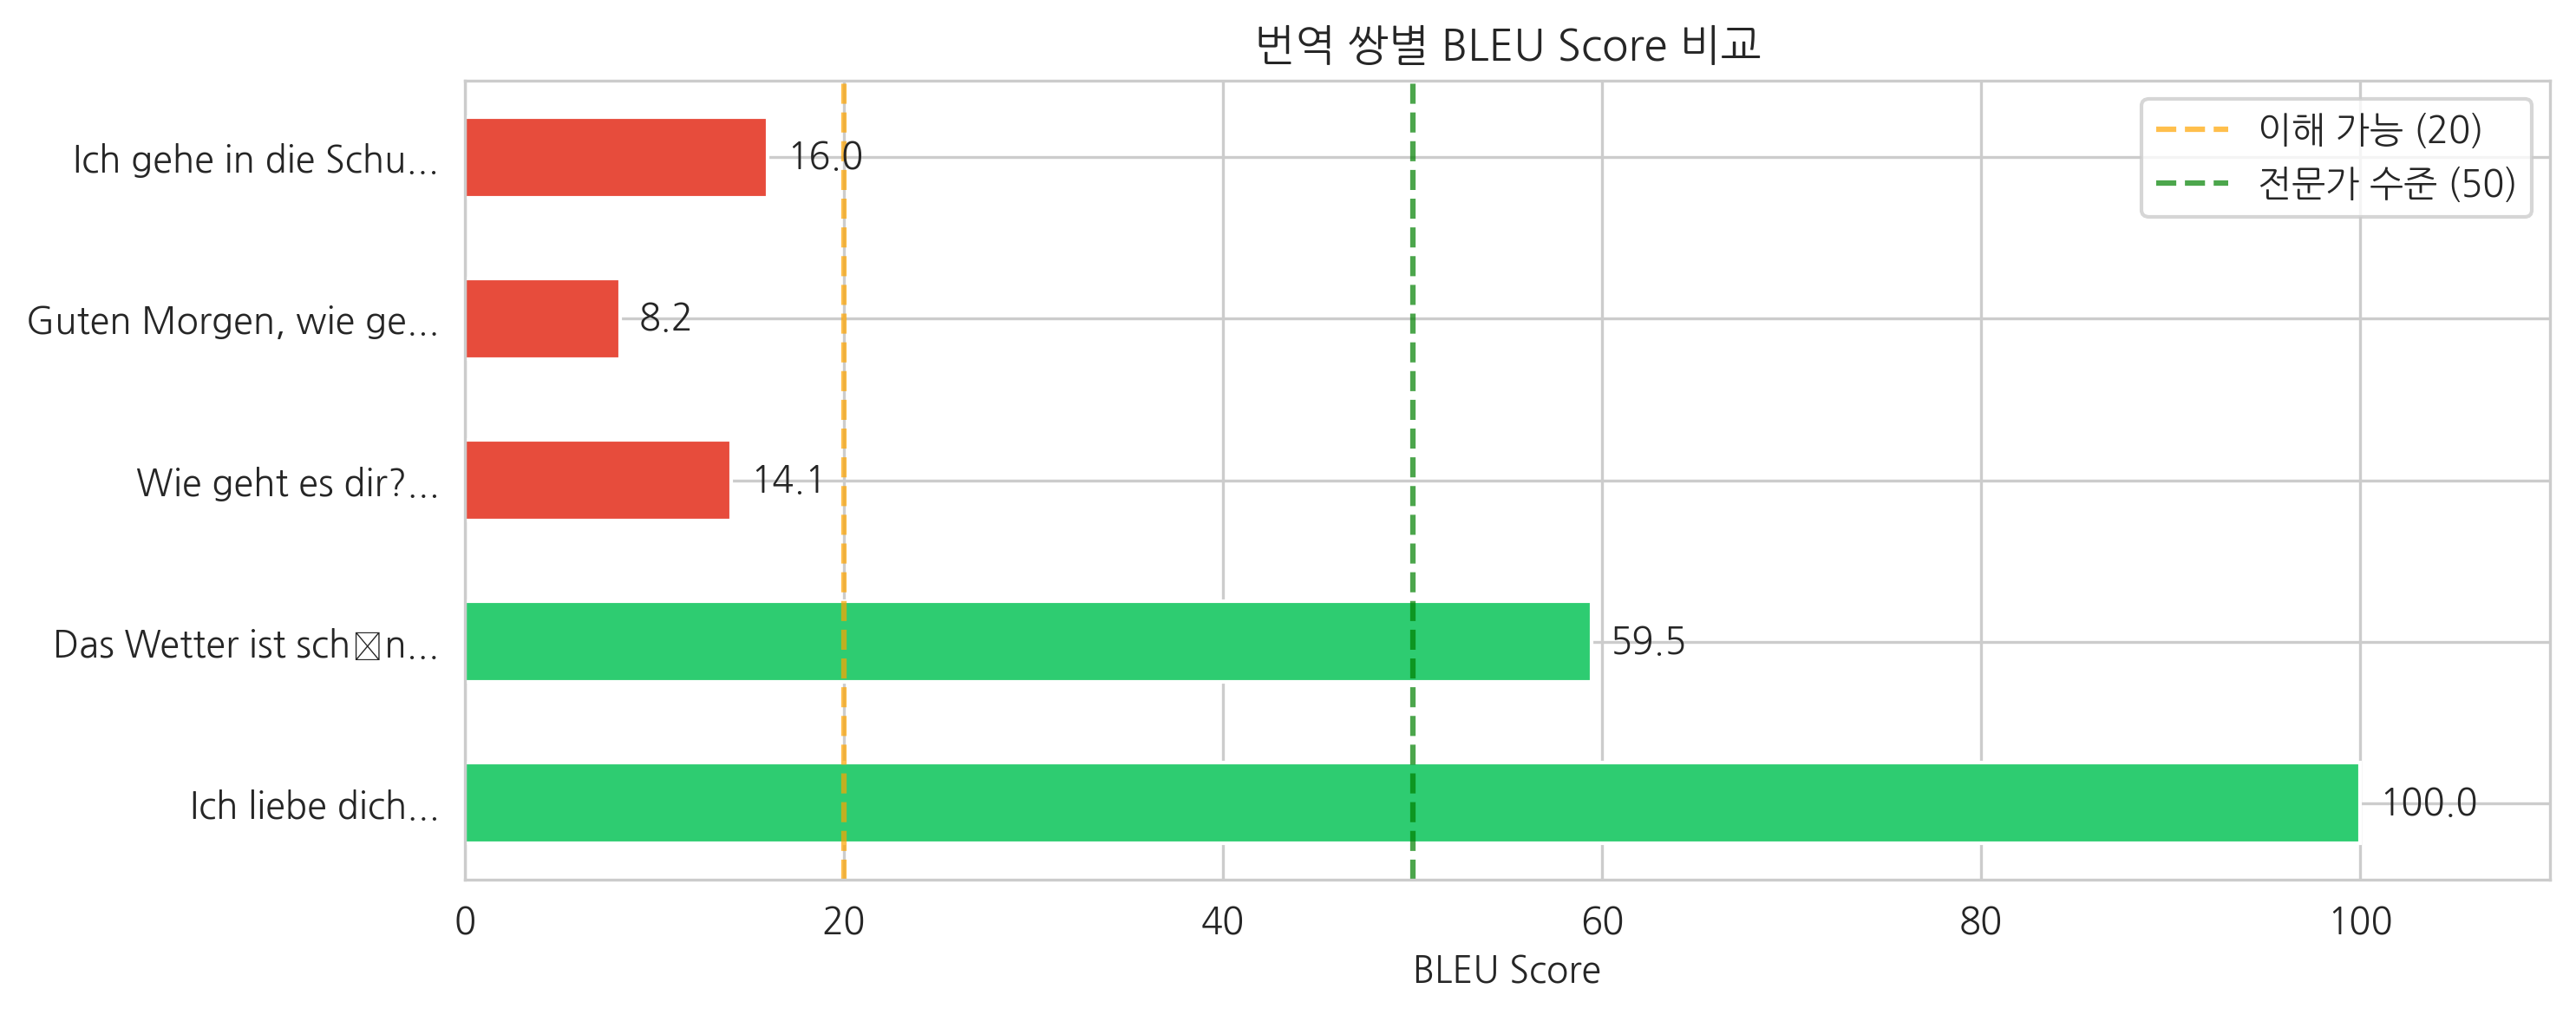

In [24]:
# BLEU Score 시각화: 번역 품질 스펙트럼
pairs_for_viz = [
    ("Ich liebe dich",            "I love you",               "I love you"),
    ("Das Wetter ist schön",      "The weather is beautiful",  "The weather is nice"),
    ("Wie geht es dir?",          "How are you?",              "How do you do?"),
    ("Guten Morgen, wie geht es?","Good morning, how are you?","Good morning"),
    ("Ich gehe in die Schule",    "I go to school",            "I am going somewhere"),
]

labels, scores = [], []
for de, en_ref, en_hyp in pairs_for_viz:
    sc = sentence_bleu(en_hyp, en_ref)
    labels.append(f"{de[:20]}...")
    scores.append(sc)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if s >= 50 else '#f39c12' if s >= 20 else '#e74c3c' for s in scores]
bars = ax.barh(labels, scores, color=colors, edgecolor='white', height=0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}', va='center', fontweight='bold')

ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='이해 가능 (20)')
ax.axvline(50, color='green',  linestyle='--', alpha=0.7, label='전문가 수준 (50)')
ax.set_xlabel('BLEU Score')
ax.set_title('번역 쌍별 BLEU Score 비교', fontweight='bold')
ax.legend()
ax.set_xlim(0, 110)

plt.tight_layout()
plt.savefig('bleu_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## ⚙️ 6. Seq2Seq 입력 데이터 준비

### 6.1 패딩(Padding)이 필요한 이유

GPU는 **배치(batch) 단위**로 병렬 처리합니다.  
그런데 문장마다 길이가 다르면 행렬을 만들 수 없습니다.

```
문장 A: [SOS, 5, 23, 42, EOS]             → 길이 5
문장 B: [SOS, 7, 31, 15, 8, 19, EOS]      → 길이 7
문장 C: [SOS, 4, 12, EOS]                  → 길이 4

패딩 후 (max_len=7):
문장 A: [SOS, 5, 23, 42, EOS, PAD, PAD]
문장 B: [SOS, 7, 31, 15,  8,  19, EOS]
문장 C: [SOS, 4, 12, EOS, PAD, PAD, PAD]
```

In [25]:
def encode_sentence(tokens: list, vocab: Vocabulary,
                    max_len: int, add_sos_eos: bool = True) -> list:
    """
    토큰 리스트를 고정 길이 인덱스 배열로 변환
    1. encode (str → int)
    2. SOS / EOS 추가 (옵션)
    3. max_len에 맞게 자르거나 PAD로 채우기
    """
    ids = vocab.encode(tokens)
    if add_sos_eos:
        ids = [vocab.SOS] + ids + [vocab.EOS]

    # truncate
    ids = ids[:max_len]
    # pad
    ids = ids + [vocab.PAD] * (max_len - len(ids))
    return ids


def prepare_dataset(df: pd.DataFrame,
                    en_vocab: Vocabulary,
                    de_vocab: Vocabulary,
                    max_len: int = 20):
    """
    DataFrame → (src_array, tgt_array) numpy 배열 반환
    src: 영어 (encoder input)
    tgt: 독일어 (decoder input / target)
    """
    src_list, tgt_list = [], []
    for _, row in df.iterrows():
        src_list.append(encode_sentence(row['en_tokens'], en_vocab, max_len))
        tgt_list.append(encode_sentence(row['de_tokens'], de_vocab, max_len))
    return np.array(src_list, dtype=np.int64), np.array(tgt_list, dtype=np.int64)


MAX_LEN = 25  # SOS + 최대 23단어 + EOS

train_src, train_tgt = prepare_dataset(train_df, en_vocab, de_vocab, MAX_LEN)
val_src,   val_tgt   = prepare_dataset(val_df,   en_vocab, de_vocab, MAX_LEN)

print("✅ 데이터 준비 완료!")
print(f"   train src shape: {train_src.shape}")
print(f"   train tgt shape: {train_tgt.shape}")
print(f"   val   src shape: {val_src.shape}")
print(f"   val   tgt shape: {val_tgt.shape}")

✅ 데이터 준비 완료!
   train src shape: (4000, 25)
   train tgt shape: (4000, 25)
   val   src shape: (1000, 25)
   val   tgt shape: (1000, 25)


In [26]:
# 인코딩 결과 시각적으로 확인
print("=" * 70)
print("첫 3개 샘플 인코딩 결과")
print("=" * 70)
for i in range(3):
    en_text  = train_df.iloc[i]['english']
    de_text  = train_df.iloc[i]['german']
    src_ids  = train_src[i].tolist()
    tgt_ids  = train_tgt[i].tolist()

    # 복원
    en_decoded = en_vocab.decode(src_ids)
    de_decoded = de_vocab.decode(tgt_ids)

    print(f"[Sample {i+1}]")
    print(f"  EN 원문  : {en_text}")
    print(f"  EN 인덱스: {src_ids}")
    print(f"  EN 복원  : {en_decoded}")
    print(f"  DE 원문  : {de_text}")
    print(f"  DE 인덱스: {tgt_ids}")
    print(f"  DE 복원  : {de_decoded}")
    print()

# 패딩 비율 확인
pad_ratio = (train_src == 0).mean()
print(f"📊 PAD 비율 (train_src): {pad_ratio:.2%}")
print("   (이 비율이 너무 높으면 max_len을 줄여 메모리를 절약할 수 있습니다)")

첫 3개 샘플 인코딩 결과
[Sample 1]
  EN 원문  : Oh Tom, can you ever forgive me?
  EN 인덱스: [1, 816, 1233, 12, 196, 1374, 374, 449, 730, 16, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  EN 복원  : oh tom , can you ever forgive me ?
  DE 원문  : Ach, Tom, kannst du mir je verzeihen?
  DE 인덱스: [1, 24, 7, 1356, 7, 780, 304, 973, 754, 3, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  DE 복원  : ach , tom , kannst du mir je <UNK> ?

[Sample 2]
  EN 원문  : Take off your mask.
  EN 인덱스: [1, 1165, 812, 1377, 725, 13, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  EN 복원  : take off your mask .
  DE 원문  : Nehmen Sie die Maske ab.
  DE 인덱스: [1, 1025, 1252, 280, 948, 14, 8, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  DE 복원  : nehmen sie die maske ab .

[Sample 3]
  EN 원문  : I ordered new furniture.
  EN 인덱스: [1, 584, 832, 792, 465, 13, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  EN 복원  : i ordered new furniture .
  DE 원문  : Ich bestellte neue Möbel.
  DE 인덱스: [1, 715, 163, 1

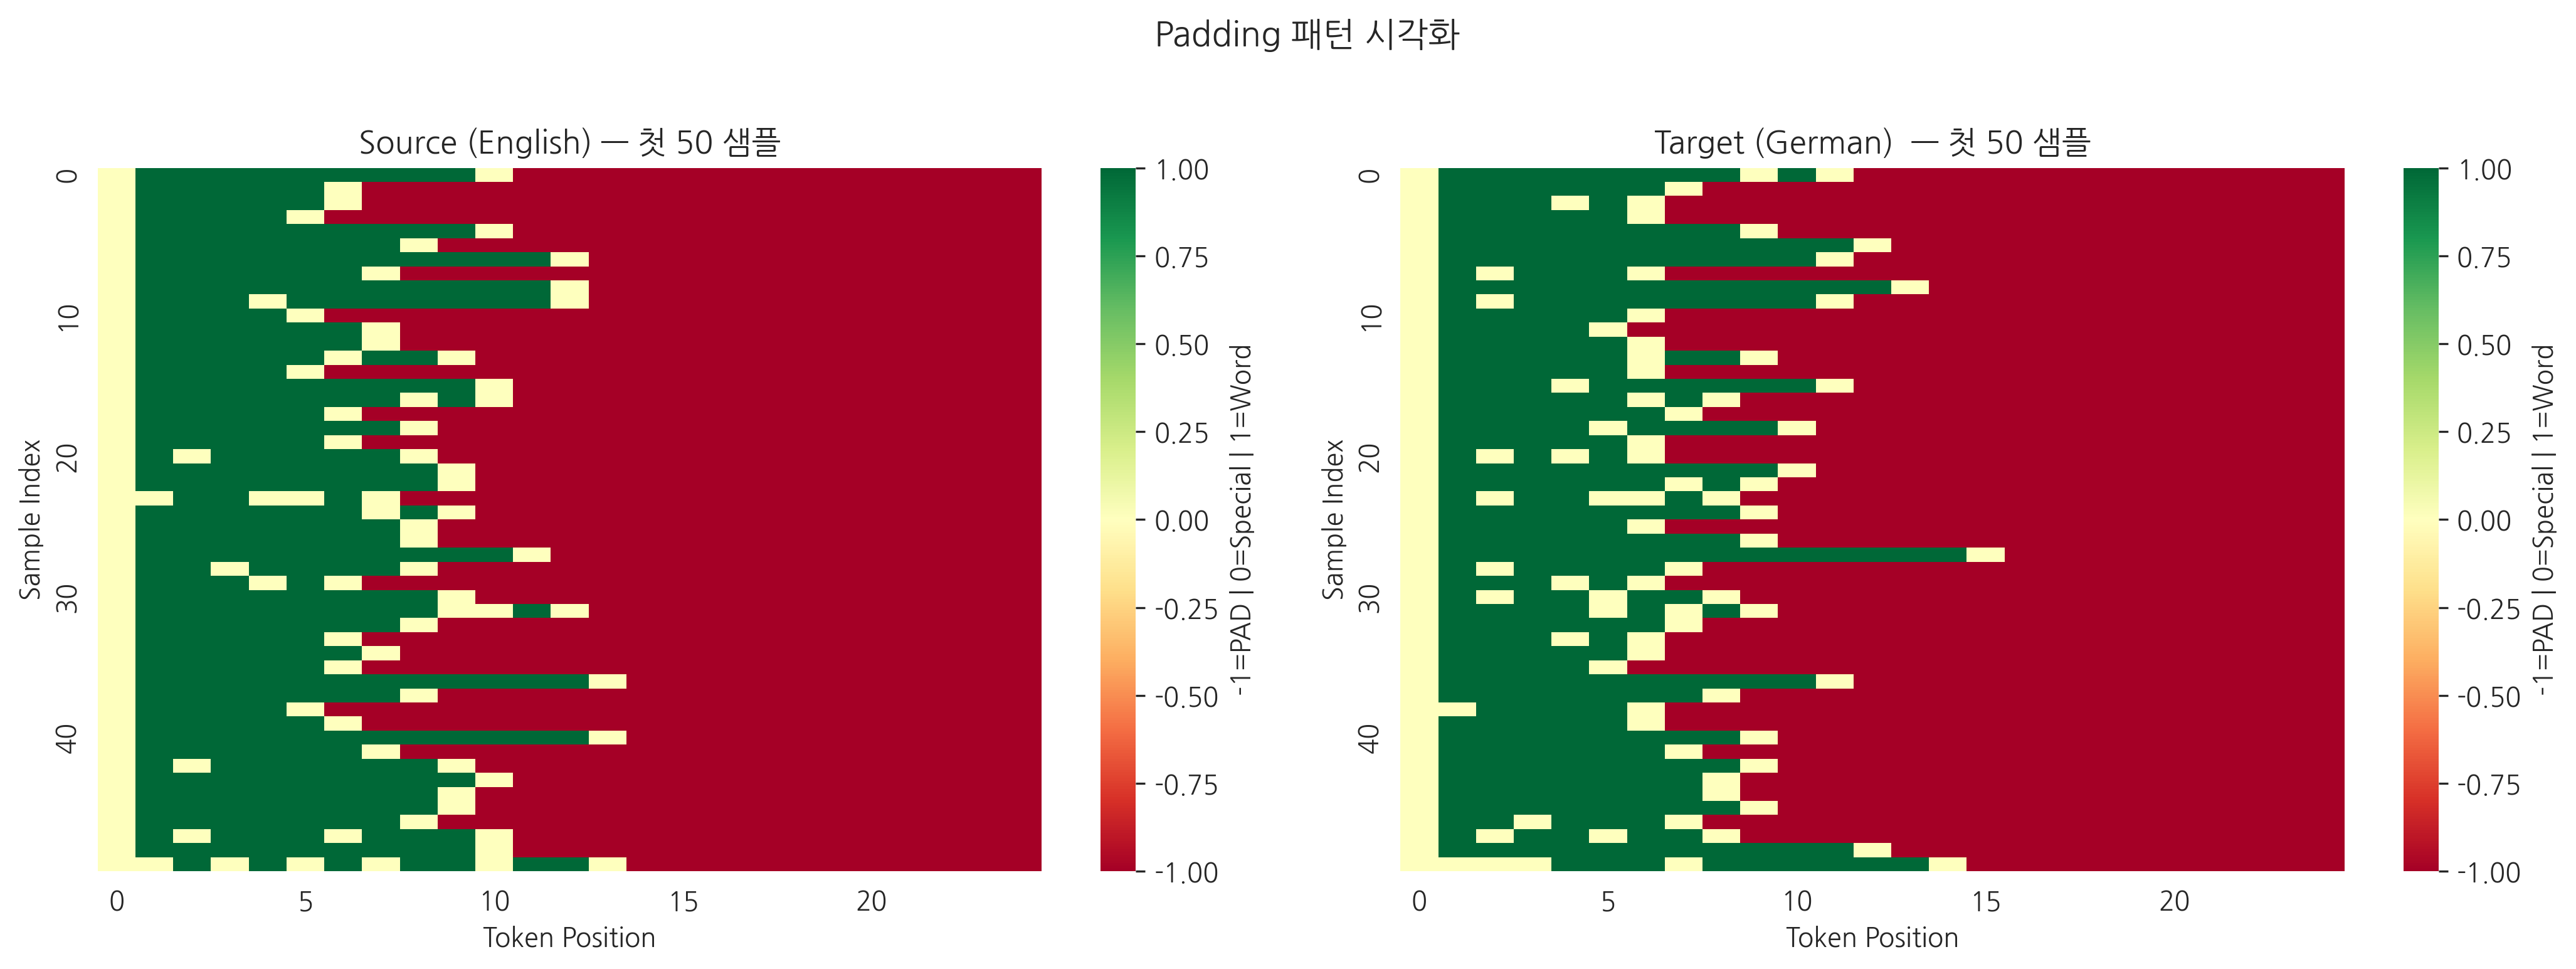

💡 녹색: 실제 단어 / 노란색: 특수 토큰(SOS/EOS) / 빨간색: PAD
   → 오른쪽으로 갈수록 PAD가 많아지는 것을 확인!


In [27]:
# 패딩 패턴 시각화 (첫 50개 샘플 히트맵)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in [
    (axes[0], train_src[:50], 'Source (English) — 첫 50 샘플'),
    (axes[1], train_tgt[:50], 'Target (German)  — 첫 50 샘플'),
]:
    # PAD=0, 특수토큰(1-3), 일반단어(4+) 구분
    display = np.where(data == 0, -1, np.where(data <= 3, 0, 1))
    sns.heatmap(display, ax=ax, cmap='RdYlGn',
                cbar_kws={'label': '-1=PAD | 0=Special | 1=Word'},
                xticklabels=5, yticklabels=10,
                linewidths=0, rasterized=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Token Position')
    ax.set_ylabel('Sample Index')

plt.suptitle('Padding 패턴 시각화', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('padding_pattern.png', dpi=100, bbox_inches='tight')
plt.show()

print("💡 녹색: 실제 단어 / 노란색: 특수 토큰(SOS/EOS) / 빨간색: PAD")
print("   → 오른쪽으로 갈수록 PAD가 많아지는 것을 확인!")

## 📈 7. MLflow 실험 기록

데이터 탐색 결과와 전처리 설정을 MLflow에 기록합니다.  
이후 Day 2-2, 2-3에서 모델 실험과 함께 비교할 수 있습니다.

In [28]:
# 커버리지 계산 (vocab이 얼마나 잘 커버하는지)
def coverage(token_lists, vocab):
    total = known = 0
    for tokens in token_lists:
        for t in tokens:
            total += 1
            if t in vocab.stoi:
                known += 1
    return known / total if total > 0 else 0.0

with mlflow.start_run(run_name='Day2-1_Data_Exploration'):

    # --- 데이터 파라미터 ---
    mlflow.log_params({
        'dataset'           : 'Tatoeba_EN-DE',
        'license'           : 'CC_BY_2.0',
        'total_samples'     : len(df),
        'train_samples'     : len(train_df),
        'val_samples'       : len(val_df),
        'min_words_filter'  : MIN_WORDS,
        'max_words_filter'  : MAX_WORDS,
        'max_seq_len'       : MAX_LEN,
        'en_freq_threshold' : en_vocab.freq_threshold,
        'de_freq_threshold' : de_vocab.freq_threshold,
    })

    # --- 데이터 통계 메트릭 ---
    mlflow.log_metrics({
        'en_vocab_size'     : len(en_vocab),
        'de_vocab_size'     : len(de_vocab),
        'en_avg_word_count' : float(df['en_word_count'].mean()),
        'de_avg_word_count' : float(df['de_word_count'].mean()),
        'en_max_word_count' : float(df['en_word_count'].max()),
        'de_max_word_count' : float(df['de_word_count'].max()),
        'en_vocab_coverage' : coverage(train_df['en_tokens'], en_vocab),
        'de_vocab_coverage' : coverage(train_df['de_tokens'], de_vocab),
        'pad_ratio_src'     : float((train_src == 0).mean()),
        'pad_ratio_tgt'     : float((train_tgt == 0).mean()),
        'val_en_unk_rate'   : en_unk,
        'val_de_unk_rate'   : de_unk,
    })

    # --- 아티팩트: 시각화 이미지 ---
    for img in ['length_distribution.png', 'zipf_law.png',
                'bleu_comparison.png', 'padding_pattern.png']:
        if os.path.exists(img):
            mlflow.log_artifact(img)

    # --- 아티팩트: 샘플 데이터 ---
    with open('sample_translations.txt', 'w', encoding='utf-8') as f:
        f.write("EN → DE 샘플 번역 (첫 20개)\n")
        f.write("=" * 50 + "\n")
        for i in range(min(20, len(train_df))):
            f.write(f"EN: {train_df.iloc[i]['english']}\n")
            f.write(f"DE: {train_df.iloc[i]['german']}\n\n")
    mlflow.log_artifact('sample_translations.txt')

    run_id = mlflow.active_run().info.run_id

print("✅ MLflow 로깅 완료!")
print(f"   Run ID: {run_id}")
print(f"   Dagshub에서 확인: https://dagshub.com/{repo_owner}/{repo_name}/experiments")

🏃 View run Day2-1_Data_Exploration at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/3/runs/e1adbd6c91c44eccae3bd6aa4915a212
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/3
✅ MLflow 로깅 완료!
   Run ID: e1adbd6c91c44eccae3bd6aa4915a212
   Dagshub에서 확인: https://dagshub.com/dev.codecompose/deeplearning-bootcamp/experiments


## 🧠 8. 핵심 개념 정리 & 다음 단계 예고

### 오늘 배운 것

**병렬 코퍼스(Parallel Corpus)**
- 동일 내용의 두 언어 문장 쌍 모음
- EN-DE는 단어 어순이 달라 Seq2Seq 학습의 좋은 재료

**토큰화 & Vocabulary**
- 문자열 → 정수 매핑 (`stoi`) + 역방향 (`itos`)
- 특수 토큰: `<PAD>=0`, `<SOS>=1`, `<EOS>=2`, `<UNK>=3`
- `freq_threshold`로 희귀 단어 처리 → 일반화 성능 ↑

**BLEU Score**
- n-gram precision 기반 번역 자동 평가
- 범위 0~100, 실무에서 30 이상이면 유의미
- 단점: 의미론적 유사도 미반영

**패딩(Padding)**
- 배치 처리를 위해 문장 길이를 `max_len`으로 통일
- `<PAD>` 토큰은 Loss 계산에서 무시해야 함 (마스킹)

---

### Day 2-2 예고: Seq2Seq 모델 구현

오늘 만든 데이터를 가지고 직접 RNN Encoder-Decoder 모델을 구현합니다!

```
[SOS, I, love, you, EOS, PAD]  ──→  Encoder (GRU)
                                          │
                               context vector (hidden state)
                                          │
                                 Decoder (GRU) ──→ [Ich, liebe, dich, EOS]
```

예상 BLEU: ~5–15 (간단한 GRU) → Day 2-3 Attention 추가 후 ~20–30으로 향상!

In [29]:
# 최종 요약 출력
print("🎉 Day 2-1 완료!")
print()
print("=" * 55)
print("  데이터 준비 현황")
print("=" * 55)
print(f"  Total samples  : {len(df):,}")
print(f"  Train / Val    : {len(train_df):,} / {len(val_df):,}")
print(f"  EN vocab size  : {len(en_vocab):,}")
print(f"  DE vocab size  : {len(de_vocab):,}")
print(f"  max_seq_len    : {MAX_LEN}")
print(f"  train_src shape: {train_src.shape}")
print(f"  train_tgt shape: {train_tgt.shape}")
print("=" * 55)
print()
print("✅ 병렬 코퍼스 로드 및 탐색 완료")
print("✅ 토큰화 구현 (NLTK word_tokenize)")
print("✅ Vocabulary 구축 (freq_threshold 적용)")
print("✅ BLEU Score 계산 및 직관 습득")
print("✅ 패딩 + SOS/EOS 포함 데이터셋 준비")
print("✅ MLflow 실험 기록 완료")
print()
print("🚀 다음: Day 2-2 — GRU Encoder-Decoder 모델 구현 & 학습")

🎉 Day 2-1 완료!

  데이터 준비 현황
  Total samples  : 5,000
  Train / Val    : 4,000 / 1,000
  EN vocab size  : 1,380
  DE vocab size  : 1,647
  max_seq_len    : 25
  train_src shape: (4000, 25)
  train_tgt shape: (4000, 25)

✅ 병렬 코퍼스 로드 및 탐색 완료
✅ 토큰화 구현 (NLTK word_tokenize)
✅ Vocabulary 구축 (freq_threshold 적용)
✅ BLEU Score 계산 및 직관 습득
✅ 패딩 + SOS/EOS 포함 데이터셋 준비
✅ MLflow 실험 기록 완료

🚀 다음: Day 2-2 — GRU Encoder-Decoder 모델 구현 & 학습


## ✅ Day 2-1 완료 체크리스트

- [ ] Tatoeba EN-DE 데이터 다운로드 및 로드
- [ ] 샘플링 필터 (단어 수 기준) 설정 완료
- [ ] EDA 완료 (문장 길이 분포, 어휘 분포, Zipf's Law)
- [ ] 토큰화 함수 구현 및 전체 데이터 적용
- [ ] Vocabulary 클래스 구현 (build / encode / decode)
- [ ] freq_threshold로 희귀 단어 처리 확인
- [ ] BLEU Score 계산 — 다양한 예시로 직관 습득
- [ ] n-gram precision 직접 계산 (1-gram ~ 4-gram)
- [ ] SOS/EOS/PAD 포함 데이터셋 완성 (train/val)
- [ ] 패딩 패턴 히트맵으로 확인
- [ ] MLflow에 실험 기록 (params, metrics, artifacts)
- [ ] Dagshub UI에서 실험 확인

## 🎯 다음 단계 (Day 2-2)

오늘 준비한 `train_src`, `train_tgt`, `en_vocab`, `de_vocab`을 그대로 사용해  
**GRU 기반 Encoder-Decoder Seq2Seq 모델**을 직접 구현하고 학습시킵니다!

```
Encoder:
  Embedding → GRU → context vector

Decoder:
  Embedding → GRU (초기 hidden = context) → Linear → Softmax
              ↑ teacher forcing으로 학습 안정화
```

예상 결과:
- Train Loss: ~2.0 이하 수렴
- Validation BLEU: ~8–15
- Day 2-3 Attention 추가 후: BLEU ~20–30 🚀

수고하셨습니다! 🎉